# Fine-tuning и аугментации YOLOv8n

Участник А. E1 — базовое дообучение; E2 — другая политика аугментаций при одинаковых данных и режиме обучения. Нет заранее заданного правильного значения mAP.

In [1]:
from pathlib import Path
import os, sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data').is_dir())
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(ROOT)


C:\Users\azatm2\projects\outpeer-cv


In [2]:
import yaml
baseline = yaml.safe_load((ROOT / 'configs/a/yolov8n_baseline.yaml').read_text())
augmented = yaml.safe_load((ROOT / 'configs/a/yolov8n_aug.yaml').read_text())
assert baseline['train'] == augmented['train']
assert baseline['seed'] == augmented['seed']
assert baseline['data'] == augmented['data']
import pandas as pd
pd.DataFrame({'baseline': baseline['augmentation'], 'augmented': augmented['augmentation']})


,baseline,augmented
hsv_h,0.015,0.015
hsv_s,0.400,0.400
hsv_v,0.300,0.300
degrees,0.000,180.000
translate,0.100,0.100
scale,0.500,0.500
shear,0.000,0.000
perspective,0.000,0.000
flipud,0.000,0.500
fliplr,0.500,0.500


## Запуск
Используйте терминал: `python -m src.training.train --config configs/a/yolov8n_baseline.yaml`, затем `... --config configs/a/yolov8n_aug.yaml`. `--dry-run` проверяет пути без обучения. На Windows training запускается отдельным процессом. Существующие результаты не перезаписываются: для повторного запуска задайте новое `--name`.

In [3]:
# Включать только осознанно: это запустит обучение на доступном устройстве.
RUN_TRAINING = False
if RUN_TRAINING:
    import subprocess
    for config in ['yolov8n_baseline.yaml', 'yolov8n_aug.yaml']:
        subprocess.run([sys.executable, '-m', 'src.training.train', '--config', f'configs/a/{config}'], check=True)


## Реальные результаты
Таблица читается из завершённых запусков; отсутствующие метрики не заменяются выдуманными числами. Smoke run проверяет совместимость модулей и не считается экспериментом качества.

In [4]:
rows = []
for path in sorted((ROOT / 'models/a').glob('*/metadata.json')):
    record = json.loads(path.read_text(encoding='utf-8'))
    rows.append({'run': record['name'], 'split': record['validation']['split'],
                 'source_images': record['dataset']['counts']['source_images'],
                 'epochs_budget': record['effective_config']['train']['epochs'],
                 **record['validation']['metrics']})
results = pd.DataFrame(rows)
results if len(results) else 'Завершённых запусков пока нет.'


,run,split,source_images,epochs_budget,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
0,a_n_aug_20,val,772,20,0.686030,0.592166,0.608125,0.243728,0.243728
1,a_n_baseline_20,val,772,20,0.691275,0.662093,0.668993,0.341712,0.341712
2,a_n_pilot5,val,50,5,0.201923,0.525000,0.442411,0.191803,0.191803
3,a_n_smoke_checked,val,43,1,0.002169,0.093750,0.001348,0.000445,0.000445
4,a_n_smoke_normalized,val,50,1,0.006296,0.425000,0.007666,0.004459,0.004459


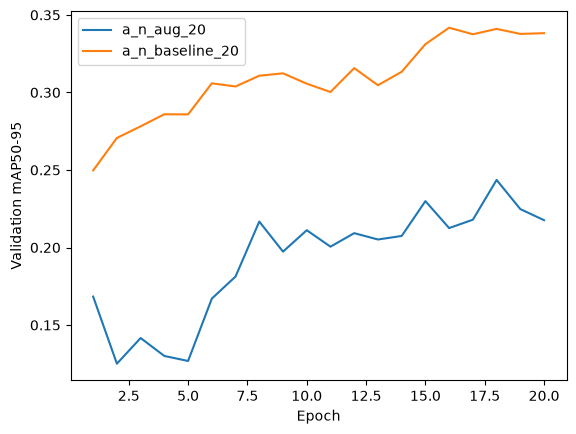

In [5]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
comparison_file = ROOT / 'reports/a/experiments/comparison.csv'
comparable_runs = set(pd.read_csv(comparison_file)['run']) if comparison_file.exists() else set()
for path in sorted((ROOT / 'runs/a').glob('*/results.csv')):
    if path.parent.name not in comparable_runs: continue
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip()
    metric = 'metrics/mAP50-95(B)'
    if metric in frame:
        plt.plot(frame['epoch'], frame[metric], label=path.parent.name)
if plt.gca().lines:
    plt.xlabel('Epoch'); plt.ylabel('Validation mAP50-95'); plt.legend(); plt.show()
else:
    plt.close()
    print('Сначала создайте проверенное сравнение командой src.training.summarize.')


## Передача участнику Б
Передайте папку `models/a/<run>/`, `data.yaml`, манифест и фиксированное разбиение. `best.pt` выбирается на validation. Друг оценивает итоговые модели одним способом и подключает выбранную модель к приложению. При одном классе вывод ограничен обнаружением мусора; классификация материалов потребует новых аннотаций.